In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device='cpu'
print(f"Using device: {device}")

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib

import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math
#import pyrender

import time
import os

import open3d as o3d
print('Using open3d version',o3d.__version__)


from blend_utils import *
from mesh_processing import *

two_pi = 2*torch.pi

Using device: cpu
Using open3d version 0.18.0


In [2]:
shapename = 'igea11706_6patch'
#layer_sizes = [2, 8, 8, 3]  
#layer_sizes = [20, 8, 8, 3]  
#layer_sizes = [8, 8, 8, 3]
#layer_sizes = [4, 8, 8, 3]
#layer_sizes = [2, 128, 128,128,128, 3]  


def posenc(x):
    p=0.2*x
    return torch.stack([ x,
                        torch.sin(p*two_pi), torch.cos(p*two_pi), 
                        torch.sin(p*two_pi*2), torch.cos(p*two_pi*2),
                        torch.sin(two_pi*p*4), torch.cos(two_pi*p*4),
                        torch.sin(two_pi*p*8), torch.cos(two_pi*p*8),
                        torch.sin(two_pi*p*16), torch.cos(two_pi*p*16)]).reshape(-1,22)



def posenc(x):
    p=0.2*x

    print('x shape', x.shape)
    out = torch.stack([ x[:,0], x[:,1]]).transpose(1,0)
    print('out', out.shape)
    return out



def posenc(x):
    p=0.2*x
    p0 = p[:,0]
    p1 = p[:,1]

    #print('x shape', x.shape)
    out = torch.stack([ p0,p1,
                      torch.sin(p0*two_pi), torch.sin(p1*two_pi),
                      torch.cos(p0*two_pi), torch.cos(p1*two_pi),
                       torch.sin(2*p0*two_pi), torch.sin(2*p1*two_pi),
                      torch.cos(2*p0*two_pi), torch.cos(2*p1*two_pi),
                       torch.sin(4*p0*two_pi), torch.sin(4*p1*two_pi),
                      torch.cos(4*p0*two_pi), torch.cos(4*p1*two_pi),
                      ]).transpose(1,0)
    #print('out', out.shape)
    return out



def posenc(x):
    p=0.2*x
    p0 = p[:,0]
    p1 = p[:,1]

    #print('x shape', x.shape)
    out = torch.stack([
                      torch.sin(p0*two_pi), torch.sin(p1*two_pi),
                      torch.cos(p0*two_pi), torch.cos(p1*two_pi),
                       torch.sin(2*p0*two_pi), torch.sin(2*p1*two_pi),
                      torch.cos(2*p0*two_pi), torch.cos(2*p1*two_pi),
                       torch.sin(4*p0*two_pi), torch.sin(4*p1*two_pi),
                      torch.cos(4*p0*two_pi), torch.cos(4*p1*two_pi),
                    torch.sin(8*p0*two_pi), torch.sin(8*p1*two_pi),
                      torch.cos(8*p0*two_pi), torch.cos(8*p1*two_pi),
                      ]).transpose(1,0)
    #print('out', out.shape)
    return out

layer_sizes = [16, 32, 3]




def posenc(x):
    p=0.2*x
    p0 = p[:,0]
    p1 = p[:,1]

    #print('x shape', x.shape)
    out = torch.stack([
                      torch.sin(p0*two_pi), torch.sin(p1*two_pi),
                      torch.cos(p0*two_pi), torch.cos(p1*two_pi),
                       torch.sin(2*p0*two_pi), torch.sin(2*p1*two_pi),
                      torch.cos(2*p0*two_pi), torch.cos(2*p1*two_pi),
                       torch.sin(4*p0*two_pi), torch.sin(4*p1*two_pi),
                      torch.cos(4*p0*two_pi), torch.cos(4*p1*two_pi),
                    torch.sin(8*p0*two_pi), torch.sin(8*p1*two_pi),
                      torch.cos(8*p0*two_pi), torch.cos(8*p1*two_pi),
        torch.sin(16*p0*two_pi), torch.sin(16*p1*two_pi),
                      torch.cos(16*p0*two_pi), torch.cos(16*p1*two_pi),
        torch.sin(32*p0*two_pi), torch.sin(32*p1*two_pi),
                      torch.cos(32*p0*two_pi), torch.cos(32*p1*two_pi),
                      ]).transpose(1,0)
    #print('out', out.shape)
    return out

layer_sizes = [24, 32, 3]



def posenc(x):
    p=0.2*x
    p0 = p[:,0]
    p1 = p[:,1]

    #print('x shape', x.shape)
    out = torch.stack([
                      torch.sin(p0*two_pi), torch.sin(p1*two_pi),
                      torch.cos(p0*two_pi), torch.cos(p1*two_pi),
                       torch.sin(2*p0*two_pi), torch.sin(2*p1*two_pi),
                      torch.cos(2*p0*two_pi), torch.cos(2*p1*two_pi),
                       torch.sin(4*p0*two_pi), torch.sin(4*p1*two_pi),
                      torch.cos(4*p0*two_pi), torch.cos(4*p1*two_pi),
                    torch.sin(8*p0*two_pi), torch.sin(8*p1*two_pi),
                      torch.cos(8*p0*two_pi), torch.cos(8*p1*two_pi),
        torch.sin(16*p0*two_pi), torch.sin(16*p1*two_pi),
                      torch.cos(16*p0*two_pi), torch.cos(16*p1*two_pi),
        torch.sin(32*p0*two_pi), torch.sin(32*p1*two_pi),
                      torch.cos(32*p0*two_pi), torch.cos(32*p1*two_pi),

        torch.sin(64*p0*two_pi), torch.sin(64*p1*two_pi),
                      torch.cos(64*p0*two_pi), torch.cos(64*p1*two_pi),

        torch.sin(128*p0*two_pi), torch.sin(128*p1*two_pi),
                      torch.cos(128*p0*two_pi), torch.cos(128*p1*two_pi)

                      ]).transpose(1,0)
    #print('out', out.shape)
    return out

layer_sizes = [32, 64, 32, 3]


'''
def posenc(x):
    p=0.2*x
    return torch.stack([ torch.sin(p*two_pi), torch.cos(p*two_pi), 
                        torch.sin(p*two_pi*2), torch.cos(p*two_pi*2)]).reshape(-1,8)


def posenc(x):
    p=0.2*x
    return torch.stack([ torch.sin(p*two_pi), torch.cos(p*two_pi) ]).reshape(-1,4)
'''

'\ndef posenc(x):\n    p=0.2*x\n    return torch.stack([ torch.sin(p*two_pi), torch.cos(p*two_pi), \n                        torch.sin(p*two_pi*2), torch.cos(p*two_pi*2)]).reshape(-1,8)\n\n\ndef posenc(x):\n    p=0.2*x\n    return torch.stack([ torch.sin(p*two_pi), torch.cos(p*two_pi) ]).reshape(-1,4)\n'

In [3]:
def B(t, device):
    return pou_blend_func(t, v=0.6).to(device)


class BNS(nn.Module):
    def __init__(self, layer_sizes, he_mesh=None, from_file=False, shapename=None, device='cpu'):
        super(BNS, self).__init__()
        self.device = device

        if not from_file:
            self.he_mesh = he_mesh
            self.patches_path = None
        else:
            self.patches_path = 'patches/' + shapename
            filepath = self.patches_path + '/coarse.obj'
            coarse_mesh_o3d = o3d.io.read_triangle_mesh(filepath)
            self.he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(coarse_mesh_o3d)

        self.V = torch.tensor(np.asarray(self.he_mesh.vertices), dtype=torch.float32).to(self.device)
        self.n = self.V.shape[0]
        self.F = np.asarray(self.he_mesh.triangles)
        self.he = self.he_mesh.half_edges

        print('Assigning a halfedge to each vertex.')
        initial_V_he = get_V_he(self.he_mesh)
        self.V_he = optimise_V_he(self.he_mesh, initial_V_he)

        self.base_triangle_verts = torch.tensor([[0.0, 0.0],
                                                  [1.0, 0.0],
                                                  [0.5, np.sqrt(3) / 2]], dtype=torch.float32).to(self.device)

        print('Computing onering data.')
        self.onerings = compute_onering_data(self.he_mesh, self.V_he)

        self.mlps = nn.ModuleList([MLP(layer_sizes).to(self.device) for _ in range(self.V.shape[0])])

        print('Computing rotations.')
        self.compute_fixed_rotations()

        self.default_coarse_points = self.V.clone()
        self.default_rotations = self.rotations

    def reset(self):
        self.rotations = self.default_rotations
        self.coarse_points = self.default_coarse_points
        self.weights = [1 for _ in range(self.n)]

    def compute_fixed_rotations(self):
        triangle_mesh = o3d.geometry.TriangleMesh()
        triangle_mesh.vertices = self.he_mesh.vertices
        triangle_mesh.triangles = self.he_mesh.triangles
        triangle_mesh.compute_vertex_normals()

        self.rotations = []
        for i in range(self.n):
            normal = torch.tensor(triangle_mesh.vertex_normals[i], dtype=torch.float32).to(self.device)
            v = self.he[self.V_he[i]].vertex_indices[1]
            dir_0 = self.V[v, :] - self.V[i, :]
            dir_0 = dir_0 - (dir_0 * normal).sum() * normal
            dir_0 = dir_0 / torch.sqrt((dir_0 * dir_0).sum())

            R = torch.stack([normal, dir_0, torch.cross(normal, dir_0)]).transpose(1, 0)
            self.rotations.append(R)

    def compute_samples_sphere(self, x):
        bary = barycentric_coordinates(x[:, 0], x[:, 1]).to(self.device)
        embedded_triangles = []
        for triangle_index in range(self.F.shape[0]):
            verts = self.V[self.F[triangle_index, :]]
            embedded_triangles.append(bary @ verts)
        embedded_triangles = torch.stack(embedded_triangles)
        norms = torch.norm(embedded_triangles, dim=-1, keepdim=True)
        target_shape = embedded_triangles / norms
        return target_shape, embedded_triangles, bary

    def compute_samples(self, num_samples=10000):
        if self.patches_path is None:
            raise TypeError("The BlendedMLP object has no patches filepath.")

        uv_samples = []
        target = []

        for i in range(self.F.shape[0]):
            filepath = os.path.join(self.patches_path, f"{i}_param.obj")
            mesh = o3d.io.read_triangle_mesh(filepath)

            V = torch.from_numpy(np.asarray(mesh.vertices)).float().to(self.device)
            F = torch.from_numpy(np.asarray(mesh.triangles)).long()
            UV = torch.from_numpy(np.asarray(mesh.triangle_uvs).reshape(-1, 3, 2)).float().to(self.device)

            v0, v1, v2 = V[F[:, 0]], V[F[:, 1]], V[F[:, 2]]
            face_areas = 0.5 * torch.norm(torch.cross(v1 - v0, v2 - v0, dim=1), dim=1)
            probs = face_areas / face_areas.sum()
            face_ids = torch.multinomial(probs, num_samples, replacement=True)

            u = torch.rand(num_samples, 1, device=self.device)
            v = torch.rand(num_samples, 1, device=self.device) * (1 - u)
            w = 1 - u - v
            bary = torch.cat([u, v, w], dim=1).unsqueeze(-1)

            tri_uvs = UV[face_ids]
            tri_verts = V[F[face_ids]]

            face_uv_samples = (tri_uvs * bary).sum(dim=1)
            face_target = (tri_verts * bary).sum(dim=1)

            uv_samples.append(face_uv_samples.unsqueeze(0))
            target.append(face_target.unsqueeze(0))

        uv_samples = torch.cat(uv_samples, dim=0)
        target = torch.cat(target, dim=0)

        x = uv_samples
        bary = barycentric_coordinates(x[:, :, 0], x[:, :, 1]).to(self.device)

        print('uv, bary', uv_samples.shape, bary.shape)

        return uv_samples, target, bary, []

    def onering_coords(self, x, i, j, angle, stretch):
        v = x - self.base_triangle_verts[i]
        r = torch.sqrt(v.pow(2).sum(-1))
        theta = torch.atan2(v[:, 1], v[:, 0])

        theta -= i * (two_pi / 3)
        theta = theta + (theta < 0) * two_pi

        new_theta = stretch * -1 * theta + (j * angle)
        new_theta = new_theta + (new_theta < 0) * two_pi
        new_theta = new_theta - (new_theta > two_pi) * two_pi

        onering_x = torch.stack([r * torch.cos(new_theta), r * torch.sin(new_theta)]).float().transpose(1, 0).to(self.device)
        return onering_x, r, theta, new_theta

    def save_mlps(self, filename="mlps.pth"):
        torch.save({'mlps_state_dict': [mlp.state_dict() for mlp in self.mlps]}, filename)

    def load_mlps(self, filename="mlps.pth"):
        checkpoint = torch.load(filename, map_location=self.device)
        for mlp, state_dict in zip(self.mlps, checkpoint['mlps_state_dict']):
            mlp.load_state_dict(state_dict)

    def forward(self, x, zero_test=False):
        f = torch.zeros((self.F.shape[0], x.shape[1], 3), device=self.device)
        scalar_field_for_testing = {'blend': np.zeros(f.shape),
                                    'angle': np.zeros(f.shape)}

        for triangle_index in range(self.F.shape[0]):
            verts = self.F[triangle_index, :]
            virtual_vertex = (self.V[verts[0]] + self.V[verts[1]] + self.V[verts[2]]) / 3
            blendsum = torch.zeros((x.shape[1], 1), device=self.device)

            for i in range(3):
                onering = self.onerings[verts[i]]
                j = onering['triangles'].index(triangle_index)
                onering_x, r, theta, new_theta = self.onering_coords(x[triangle_index, :, :].squeeze(), i, j, onering['angle'], onering['angle_stretch'])

                b_r = B(r, self.device).unsqueeze(-1)

                if zero_test:
                    f[triangle_index, :, :] += b_r * self.V[verts[i]]
                else:
                    f[triangle_index, :, :] += b_r * (self.mlps[verts[i]](posenc(onering_x).to(self.device)) @ self.rotations[verts[i]] + self.V[verts[i]])

                blendsum += b_r

            f[triangle_index, :, :] += (-1 * blendsum + 1) * virtual_vertex

        return f, scalar_field_for_testing


In [4]:
def show_f(f, colors):
    # Assuming target_train is already defined (Shape: [num_triangles, 4330, 3])
    num_triangles = f.shape[0]
    
    # Flatten points and colors to create a single point cloud
    points = f.reshape(-1, 3)  # Shape: e.g. [(80 * 4330), 3]
    
    # Create Open3D PointCloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)   # Assign points
    #pcd.colors = o3d.utility.Vector3dVector(np.random.uniform(size=points_np.shape))   # Assign per-triangle colors
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)   # Assign per-triangle colors
    
    # Visualize the point cloud
    o3d.visualization.draw_geometries([pcd], window_name="Colored 3D Point Cloud")
    #o3d.visualization.draw_geometries([pcd, he_mesh], window_name="Colored 3D Point Cloud")

    #o3d.visualization.draw([pcd])
    #o3d.visualization.draw([pcd, he_mesh])
    
def show_stuff( settings=[]):

    

    if 'error' in settings:
    
        error_color  = cm.Reds( 500*np.abs((output_train - target_train)**2).sum(-1) )[:,:-1]
        colors=error_color
        #colors = np.tile( error_color , (target_train.shape[0], 1)  )
        print(colors.shape)
        show_f(output_train.detach().numpy(), colors)
        show_f(target_train, colors)
        
    if 'bary' in settings:
    
        colors = bary.transpose(0, 2, 1).reshape(-1, 3)
        
        show_f(output_train.detach().numpy(), colors)
        show_f(target_train, colors)
        
    if 'blend' in settings:
        colors = scalar_field_for_testing['blend'].detach().numpy().reshape(-1,3)
        show_f(output_train.detach().numpy(), colors)
        #show_f(embedded_triangles.detach().numpy(), colors)
        show_f(target_train, colors)

    if settings == []:
        show_f(output_train.detach().numpy(), None)
        #show_f(embedded_triangles.detach().numpy(), None)
        show_f(target_train, None)
    
    '''
    colors = np.tile(bary, (target_train.shape[0], 1))
    show_f(embedded_triangles.detach().numpy(), colors)
    show_f(target_train, colors)
    show_f(output_train.detach().numpy(), colors)
    '''
    if 'angle' in settings:
    
        colors = scalar_field_for_testing['angle'].reshape(-1,3)
        show_f(output_train.detach().numpy(), colors)
        #show_f(embedded_triangles.detach().numpy(), colors)

    

In [5]:
'''
#Plotting Blend Functions

x=torch.arange(0,1,0.001)
for v in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    #plt.plot(x, B(x,v=v))
    #plt.plot(x,B(1-x,v=v))
    plt.plot(x, B(x,v=v)+B(1-x,v=v), label=v)
plt.legend()
plt.show()

x=torch.arange(0,1,0.001)
for v in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    #plt.plot(x, B(x,v=v))
    #plt.plot(x,B(1-x,v=v))
    plt.plot(x, B(x,v=v), label=v)
plt.legend()
plt.show()
'''


'\n#Plotting Blend Functions\n\nx=torch.arange(0,1,0.001)\nfor v in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:\n    #plt.plot(x, B(x,v=v))\n    #plt.plot(x,B(1-x,v=v))\n    plt.plot(x, B(x,v=v)+B(1-x,v=v), label=v)\nplt.legend()\nplt.show()\n\nx=torch.arange(0,1,0.001)\nfor v in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:\n    #plt.plot(x, B(x,v=v))\n    #plt.plot(x,B(1-x,v=v))\n    plt.plot(x, B(x,v=v), label=v)\nplt.legend()\nplt.show()\n'

In [6]:
### Defining the Blended Neural Surface (BNS)
'''
#analytic target shape test

filename = 'data/surfaces/two_triangles.off'
coarse_mesh_o3d = o3d.io.read_triangle_mesh(filename)
coarse_he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(coarse_mesh_o3d)
#coarse_he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(o3d.geometry.TriangleMesh.create_tetrahedron())
#coarse_he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(o3d.geometry.TriangleMesh.create_icosahedron())
#coarse_he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(o3d.geometry.TriangleMesh.create_octahedron())

n_faces = np.asarray(coarse_he_mesh.triangles.shape[0])
t_train = torch.rand(10000, 2)
mask = ( t_train[:,1] <= np.sqrt(3)*t_train[:,0] )*( t_train[:,1] <= np.sqrt(3)*(1-t_train[:,0]) ) 
t_train = t_train[mask,:]
t_train = t_train.unsqueeze(0).repeat(n_faces,1,1)

target_train, embedded_triangles, bary = bns.compute_samples_sphere(t_train)


bns = BNS(layer_sizes, from_file=False, shapename= None)

'''





#non-analytic shape test


bns = BNS(layer_sizes, from_file=True, shapename= shapename)

t_train, target_train, bary, embedded_triangles = bns.compute_samples(num_samples=100000)






Assigning a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

Computing onering data.
Computing rotations.
uv, bary torch.Size([6, 100000, 2]) torch.Size([6, 3, 100000])


/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_81840/1260754730.py:62: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1724557166878/work/aten/src/ATen/native/Cross.cpp:66.)
  R = torch.stack([normal, dir_0, torch.cross(normal, dir_0)]).transpose(1, 0)


In [7]:
t_train.shape

torch.Size([6, 100000, 2])

In [8]:
#blended_mlp.load_mlps('models/temp.pth')

In [9]:
target_train.shape

torch.Size([6, 100000, 3])

In [10]:
output_train, scalar_field_for_testing  = bns.forward(t_train, zero_test=True)


In [11]:
scalar_field_for_testing

{'blend': array([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],
 
        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],
 
        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],
 
        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],
 
        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],
 
        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]]),
 'angle': array([[[0., 0., 0.],
         [0., 0., 0.],
      

In [12]:
show_stuff( settings=[ 'angle'])

In [13]:
epoch=0

losses=[]
epochs=[]
times=[]

loss=99999


Epoch 0, Loss: 0.18769258, Time: 11.274792909622192
saved checkpoint


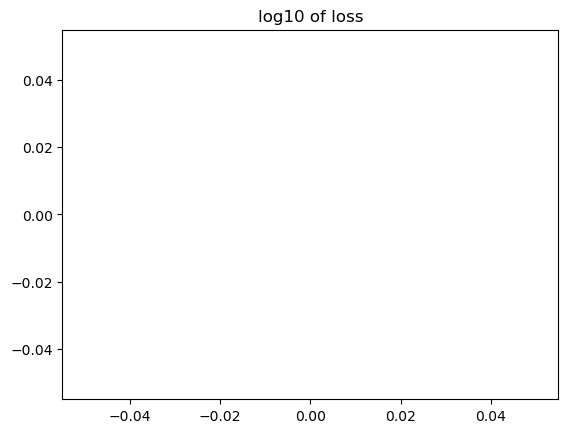

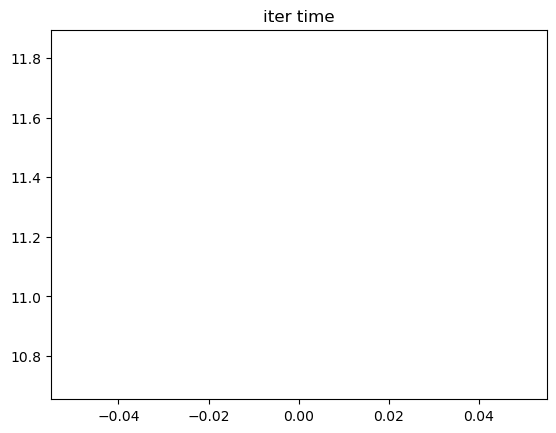

Epoch 10, Loss: 0.01527227, Time: 8.965154886245728



KeyboardInterrupt



In [14]:
%matplotlib inline


# Training all models jointly
optimizer = optim.Adam(bns.parameters(), lr=0.01)#fast lr to start


# Training loop
while loss > 0.0005:
    time_A=time.time()
    
    optimizer.zero_grad()
    output_train, scalar_field_for_testing = bns(t_train)
    

    loss = (output_train-target_train).pow(2).sum(-1).mean()
    loss.backward()
    optimizer.step()

    time_B=time.time()

    ##################################################

    this_time=time_B-time_A
    times.append(this_time)

    # Corrected indentation for if condition
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.8f}, Time: {this_time}")

    if epoch%200 ==0:
        bns.save_mlps('models/temp.pth')
        print('saved checkpoint')
        plt.plot(np.log10(losses))
        plt.title('log10 of loss')
        plt.show()
        plt.plot(times)
        plt.title('iter time')
        plt.show()
        
        

    losses.append(loss.detach())
    
    epoch += 1  # Increment epoch counter


In [ ]:
# Training all models jointly
optimizer = optim.Adam(bns.parameters(), lr=0.0001) #slower lr to end


# Training loop
while loss > 0.0:
    time_A=time.time()
    
    optimizer.zero_grad()
    output_train, scalar_field_for_testing = bns(t_train)
    

    loss = (output_train-target_train).pow(2).sum(-1).mean()
    loss.backward()
    optimizer.step()

    time_B=time.time()

    ##################################################

    this_time=time_B-time_A
    times.append(this_time)

    # Corrected indentation for if condition
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.8f}, Time: {this_time}")

    if epoch%200 ==0:
        bns.save_mlps('models/temp.pth')
        print('saved checkpoint')
        plt.plot(np.log10(losses))
        plt.title('log10 of loss')
        plt.show()
        plt.plot(times)
        plt.title('iter time')
        plt.show()
        
        

    losses.append(loss.detach())
    
    epoch += 1  # Increment epoch counter


In [ ]:
import visuals
import importlib
importlib.reload(visuals)
from visuals import *
bns.shapename = 'igea11706_6patch'

bns_visualiser = BNS_visualiser(bns, mesh_res=8, zero_test=False)

bns_visualiser.push_triangles_through()

In [ ]:
#bns.reset()
#show_stuff(settings = ['error'])
#show_stuff(settings = ['blend'])

In [ ]:
#bns = blended_mlp

In [ ]:
########### Translation Equivariance ############
bns.reset()

output_train, scalar_field_for_testing  = bns.forward(t_train)
show_stuff()

bns.V = blended_mlp.V + 2.0
bns.compute_fixed_rotations()

output_train, scalar_field_for_testing  = bns.forward(t_train)
show_stuff()
bns.reset()

In [ ]:
############# Rotation Equivariance ############
bns.reset()
output_train, scalar_field_for_testing  = bns.forward(t_train)
show_stuff()
R = torch.tensor([[0.0, 1.0, 0.0 ],
                  [-1.0, 0.0, 0.0 ],
                 [0.0, 0.0, 1.0]])

bns.coarse_points = bns.coarse_points @ R

bns.compute_fixed_rotations()

output_train, scalar_field_for_testing  = bns.forward(t_train)
show_stuff()
bns.reset()

In [ ]:
############# Translating a Single Coarse Vertex ############
bns.reset()

output_train, scalar_field_for_testing  = bns.forward(t_train)
show_stuff()

T = torch.zeros_like(bnsp.V)
T[0,:] = torch.tensor([-0.1, +0.1, 0.0 ])

bns.V = blended_mlp.V + T

bns.compute_fixed_rotations()

output_train, scalar_field_for_testing  = bns.forward(t_train)
show_stuff()
bns.reset()

In [ ]:
#bns.save_mlps('models/sphere4_4patch_nobug.pth')

In [ ]:

#bns.load_mlps('models/icosphere_sphere.pth')

In [ ]:
import visuals
import importlib
importlib.reload(visuals)
from visuals import *
bns.shapename = 'igea11706_6patch'
bns_visualiser = BNS_visualiser(bns, mesh_res=7)

bns_visualiser.push_triangles_through()